In [12]:
# Injection and Recovery

In [13]:
# run the import and install packages.py file 
%run install_packages.py

MIRSI Simulations - Package Dependency Checker

Checking for required packages...
✓ numpy is already installed
✓ astropy is already installed
✓ matplotlib is already installed
✓ photutils is already installed
✓ scipy is already installed

✓ All required packages are already installed!

Setup complete! You can now run the MIRSI simulations.


In [14]:
import numpy as np
import matplotlib.pyplot as plt
from photutils.aperture import CircularAperture, CircularAnnulus, aperture_photometry 
# Read in the data from the fits file 
from test_analysis import read_in_fits

## Normalize the sky 
- assign each readout median to correspond to 9.088e05 ph/pixel. 

In [15]:
zenith_sky_1_data = read_in_fits('./data/260203/zenith_sky_1')

Processing 1500 FITS files from ./data/260203/zenith_sky_1
Loaded 1500 FITS files from ./data/260203/zenith_sky_1


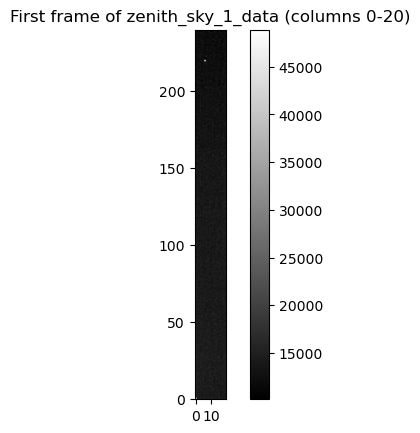

In [16]:
# Pick the first image and just preview columns 0 - 20 and all rows to see what a channel looks like
plt.imshow(zenith_sky_1_data[0, :, :20], cmap='gray', origin='lower')
plt.title("First frame of zenith_sky_1_data (columns 0-20)")
plt.colorbar()
plt.show()

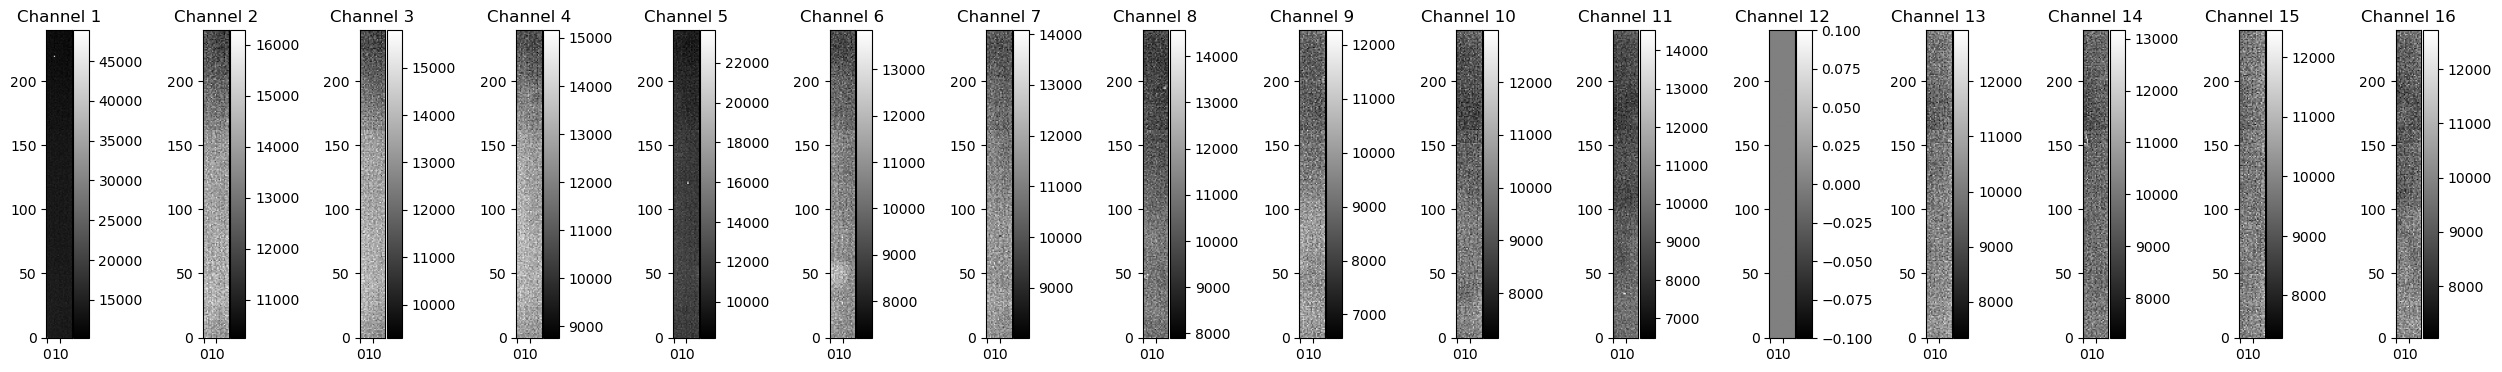

In [17]:
num_channels = 16
channel_data = []

fig, axes = plt.subplots(1, num_channels, figsize=(32, 4))

for i in range(num_channels):
    channel_data.append(zenith_sky_1_data[:, :, i*20:(i+1)*20])
    im = axes[i].imshow(channel_data[i][0], cmap='gray', origin='lower')
    axes[i].set_title("Channel {}".format(i+1))
    plt.colorbar(im, ax=axes[i], pad =0.01)

plt.show()

clearly channel 12 has something wrong with it. maybe what we can do is take the median of each and normalize the values to the "empirical sky rate".   

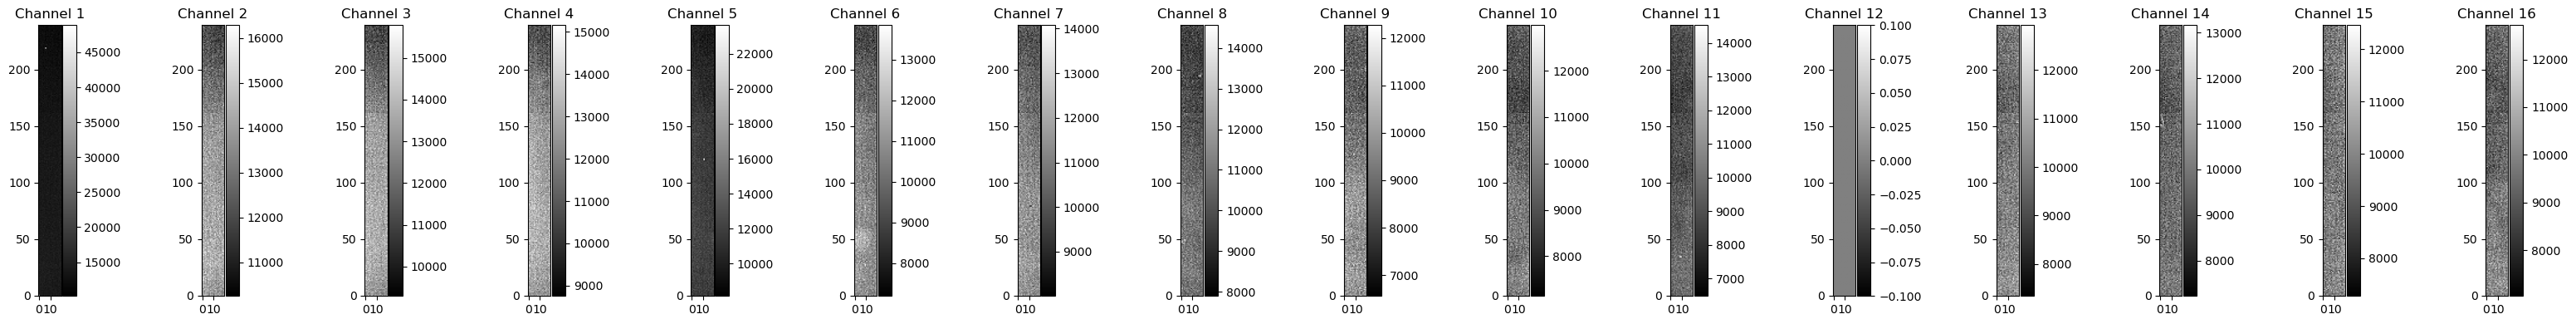

In [18]:
num_channels = 16
channel_width = 20

zenith_sky_1_data_norm = zenith_sky_1_data.astype(float).copy()

fig, axes = plt.subplots(1, num_channels, figsize=(32, 4))

for i in range(num_channels):
    c0 = i * channel_width
    c1 = (i + 1) * channel_width
    
    # first frame of normalized data for this channel
    ch0 = zenith_sky_1_data_norm[0, :, c0:c1]
    
    im = axes[i].imshow(ch0, cmap='gray', origin='lower')
    axes[i].set_title(f"Channel {i+1}")
    plt.colorbar(im, ax=axes[i], pad=0.01)

plt.tight_layout()
plt.show()

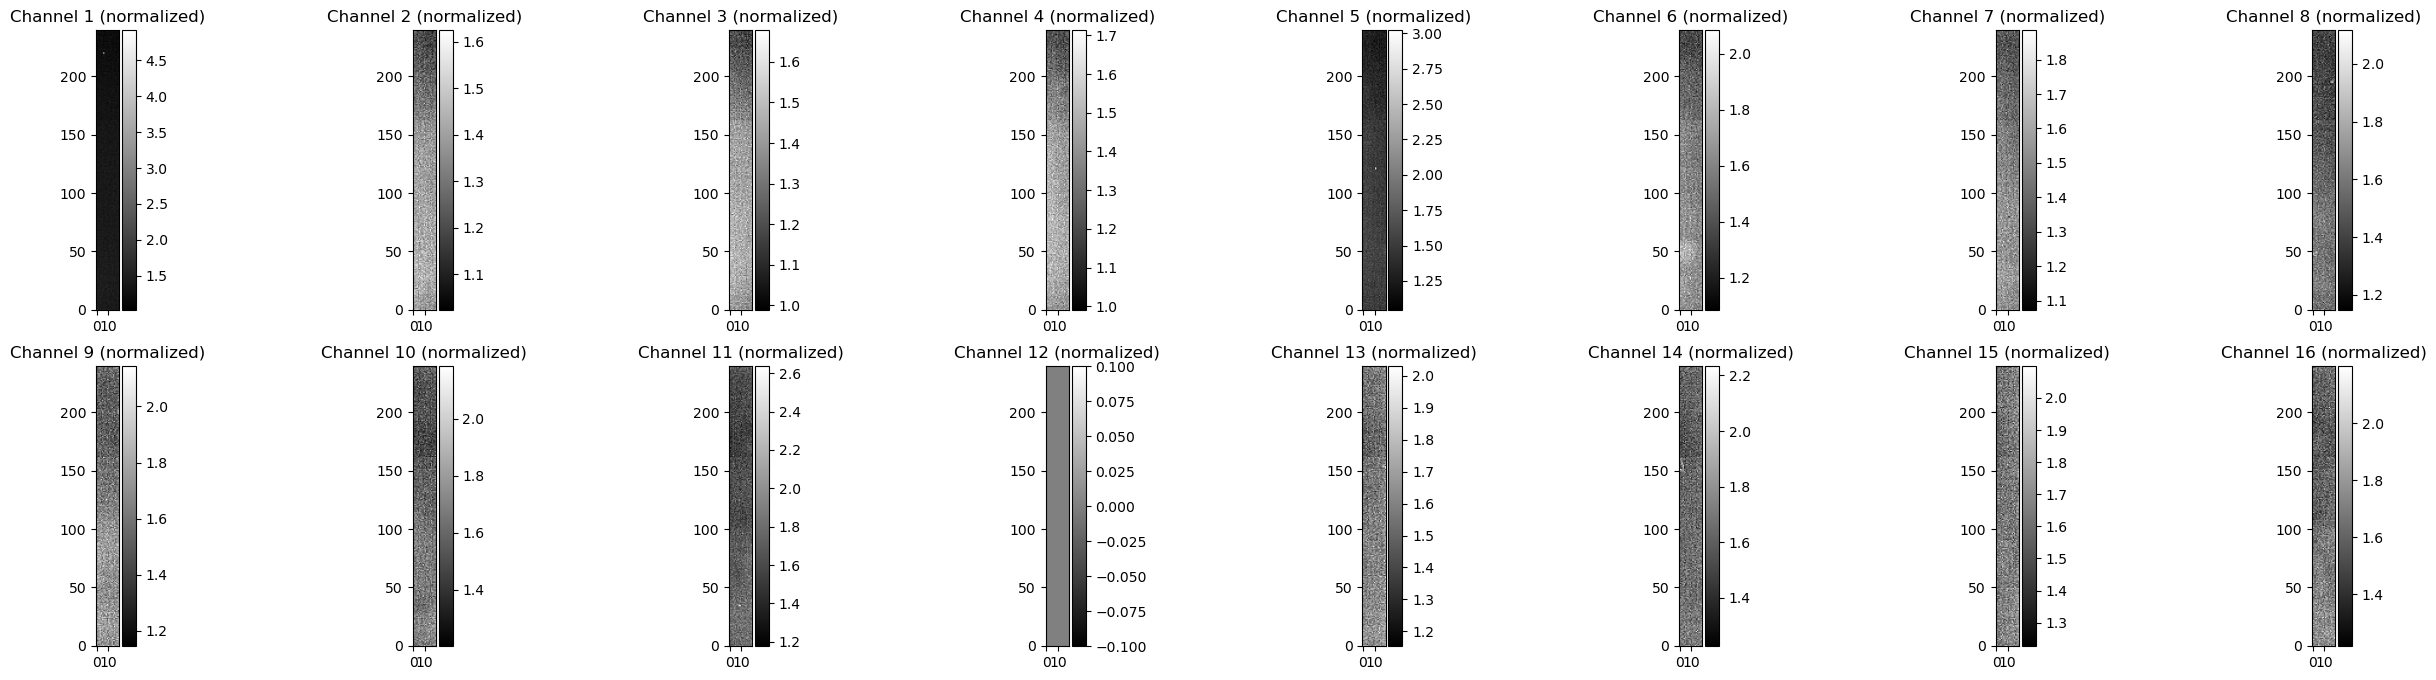

In [19]:
# normalize each channel by the median of itself 
fig, axes = plt.subplots(2, num_channels//2, figsize=(32, 8))
for i in range(num_channels):
    c0 = i * channel_width
    c1 = (i + 1) * channel_width
    channel = zenith_sky_1_data_norm[:, :, c0:c1]
    med = np.nanmedian(channel)
    if med != 0:
        zenith_sky_1_data_norm[:, :, c0:c1] = channel / med

    im = axes[i//(num_channels//2), i%(num_channels//2)].imshow(zenith_sky_1_data_norm[0, :, c0:c1], cmap='gray', origin='lower')
    axes[i//(num_channels//2), i%(num_channels//2)].set_title(f"Channel {i+1} (normalized)")
    plt.colorbar(im, ax=axes[i//(num_channels//2), i%(num_channels//2)], pad=0.01)


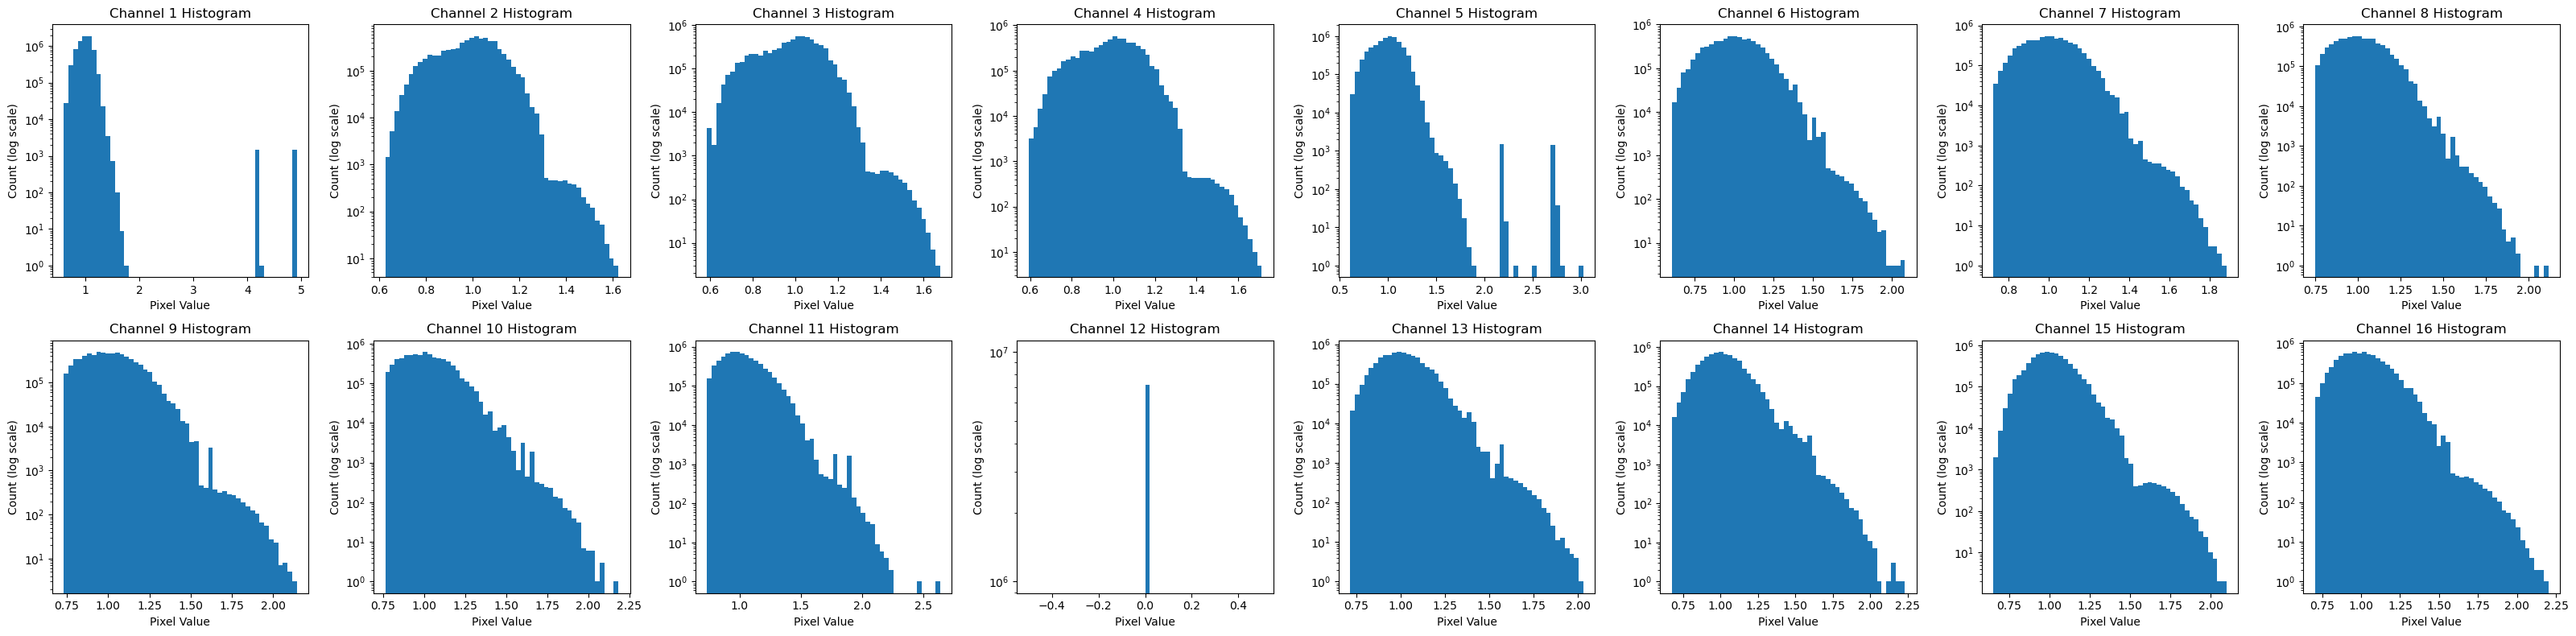

In [20]:
# histograms for each channel
fig, axes = plt.subplots(2, num_channels//2, figsize=(32, 8))
for i in range(num_channels):
    c0 = i * channel_width
    c1 = (i + 1) * channel_width
    channel = zenith_sky_1_data_norm[:, :, c0:c1]
    
    # Ignoring NaNs for histogram
    channel = channel[~np.isnan(channel)]
    axes[i//(num_channels//2), i%(num_channels//2)].hist(channel.flatten(), bins=50, log=True)
    axes[i//(num_channels//2), i%(num_channels//2)].set_title(f"Channel {i+1} Histogram")
    axes[i//(num_channels//2), i%(num_channels//2)].set_xlabel("Pixel Value")
    axes[i//(num_channels//2), i%(num_channels//2)].set_ylabel("Count (log scale)")

plt.tight_layout()
plt.show()

Now, multiply the pixel value by the expected number of sky photons

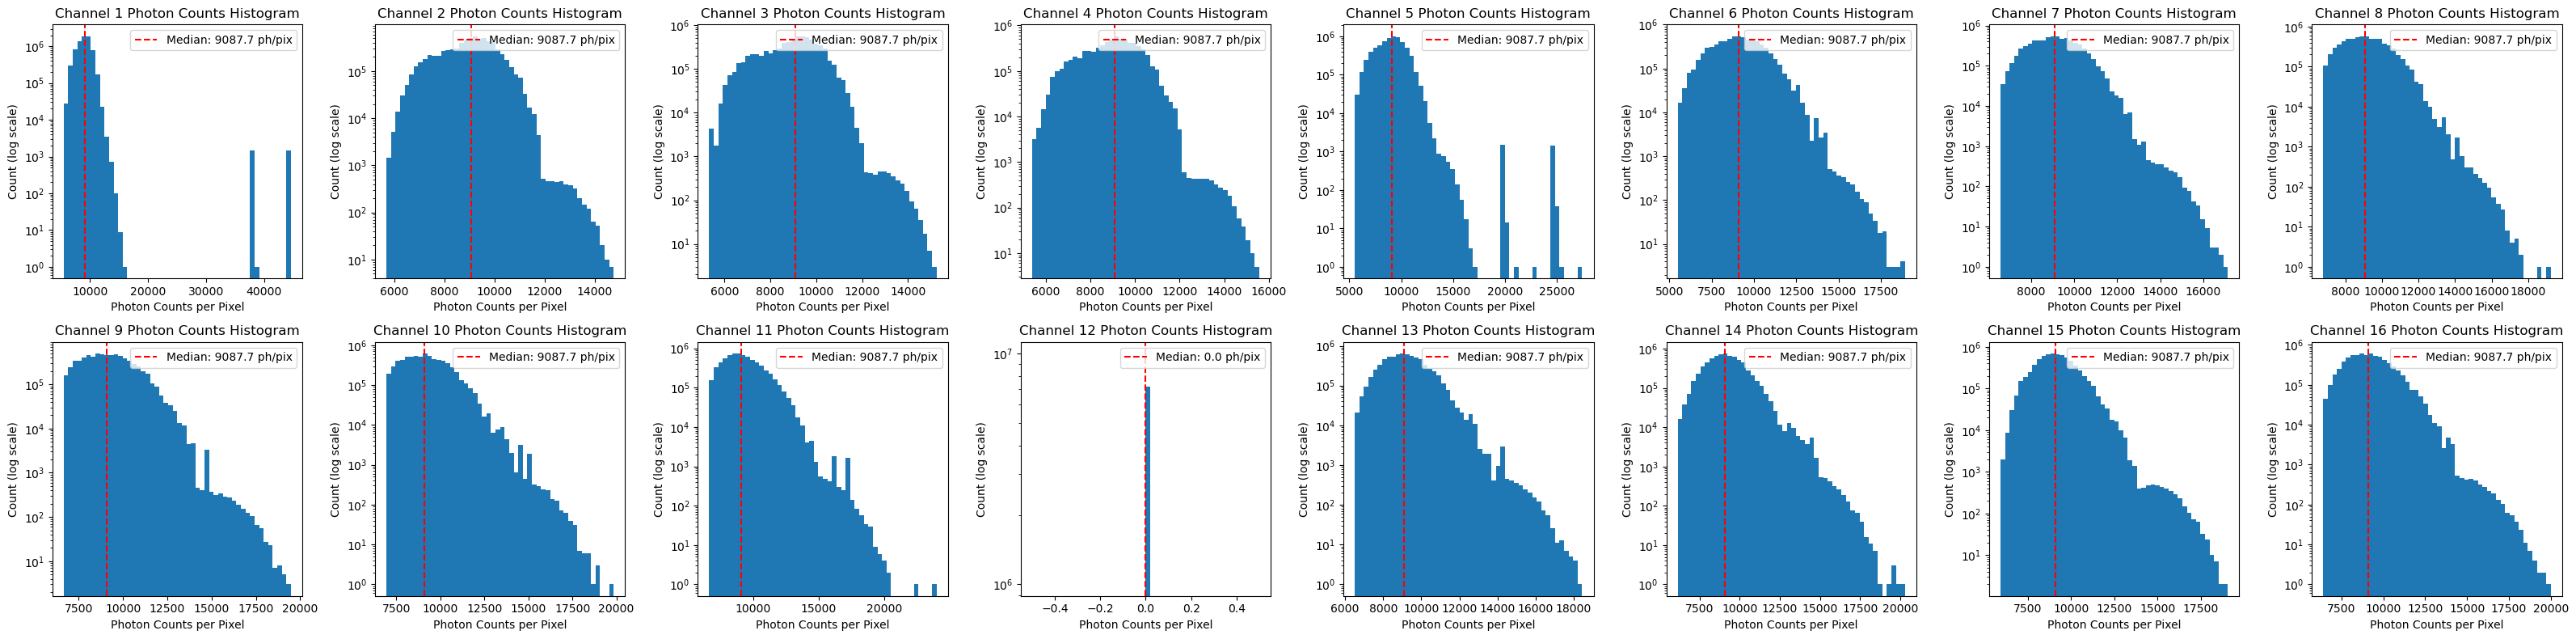

In [21]:
# Multiply each pixel value by the sky photon rate per pixel
sky_rate = 9087.657082019272 # ph/pix

# muliply zenith_sky_1_data_norm by the sky rate to get an estimate of the photon counts per pixel if not nan
zenith_sky_1_data_photons = np.where(np.isnan(zenith_sky_1_data_norm), np.nan, zenith_sky_1_data_norm * sky_rate)

# Generate histograms of the photon counts for each channel
fig, axes = plt.subplots(2, num_channels//2, figsize=(32, 8))
for i in range(num_channels):
    c0 = i * channel_width
    c1 = (i + 1) * channel_width
    channel = zenith_sky_1_data_photons[:, :, c0:c1]
    
    # Ignoring NaNs for histogram
    channel = channel[~np.isnan(channel)]
    axes[i//(num_channels//2), i%(num_channels//2)].hist(channel.flatten(), bins=50, log=True)
    axes[i//(num_channels//2), i%(num_channels//2)].set_title(f"Channel {i+1} Photon Counts Histogram")
    axes[i//(num_channels//2), i%(num_channels//2)].set_xlabel("Photon Counts per Pixel")
    axes[i//(num_channels//2), i%(num_channels//2)].set_ylabel("Count (log scale)") 

    # axvline for the median photon count in this channel
    median_photon_count = np.median(channel)
    axes[i//(num_channels//2), i%(num_channels//2)].axvline(median_photon_count, color='red', linestyle='dashed', label=f'Median: {median_photon_count:.1f} ph/pix')
    axes[i//(num_channels//2), i%(num_channels//2)].legend()
plt.tight_layout()
plt.show()

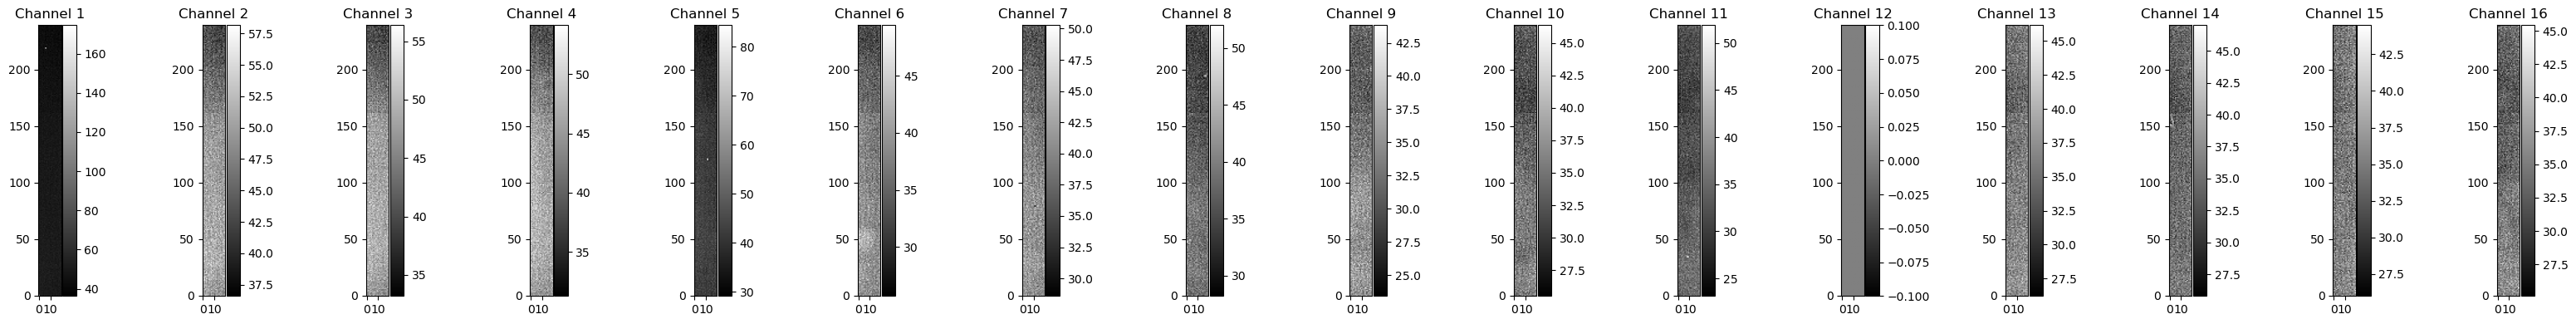

In [29]:
# Now that we have a gain measurment, we don't need to do the nomralization by the median for each channel, we can just convert the original data to photon counts directly and then analyze the timeseries. Let's do that and then compute the variance of the timeseries for each channel to see how it compares to our gain measurement.
Gain = 280 # e-/photon
#make a copy of the original data and convert to photon counts using the gain
zenith_sky_1_data_photons = zenith_sky_1_data.astype(float).copy() / Gain

#Plot the channels 
fig, axes = plt.subplots(1, num_channels, figsize=(32, 4))

for i in range(num_channels):
    c0 = i * channel_width
    c1 = (i + 1) * channel_width
    
    # first frame of normalized data for this channel
    ch0 = zenith_sky_1_data_photons[0, :, c0:c1]
    
    im = axes[i].imshow(ch0, cmap='gray', origin='lower')
    axes[i].set_title(f"Channel {i+1}")
    plt.colorbar(im, ax=axes[i], pad=0.01)

plt.tight_layout()
plt.show()

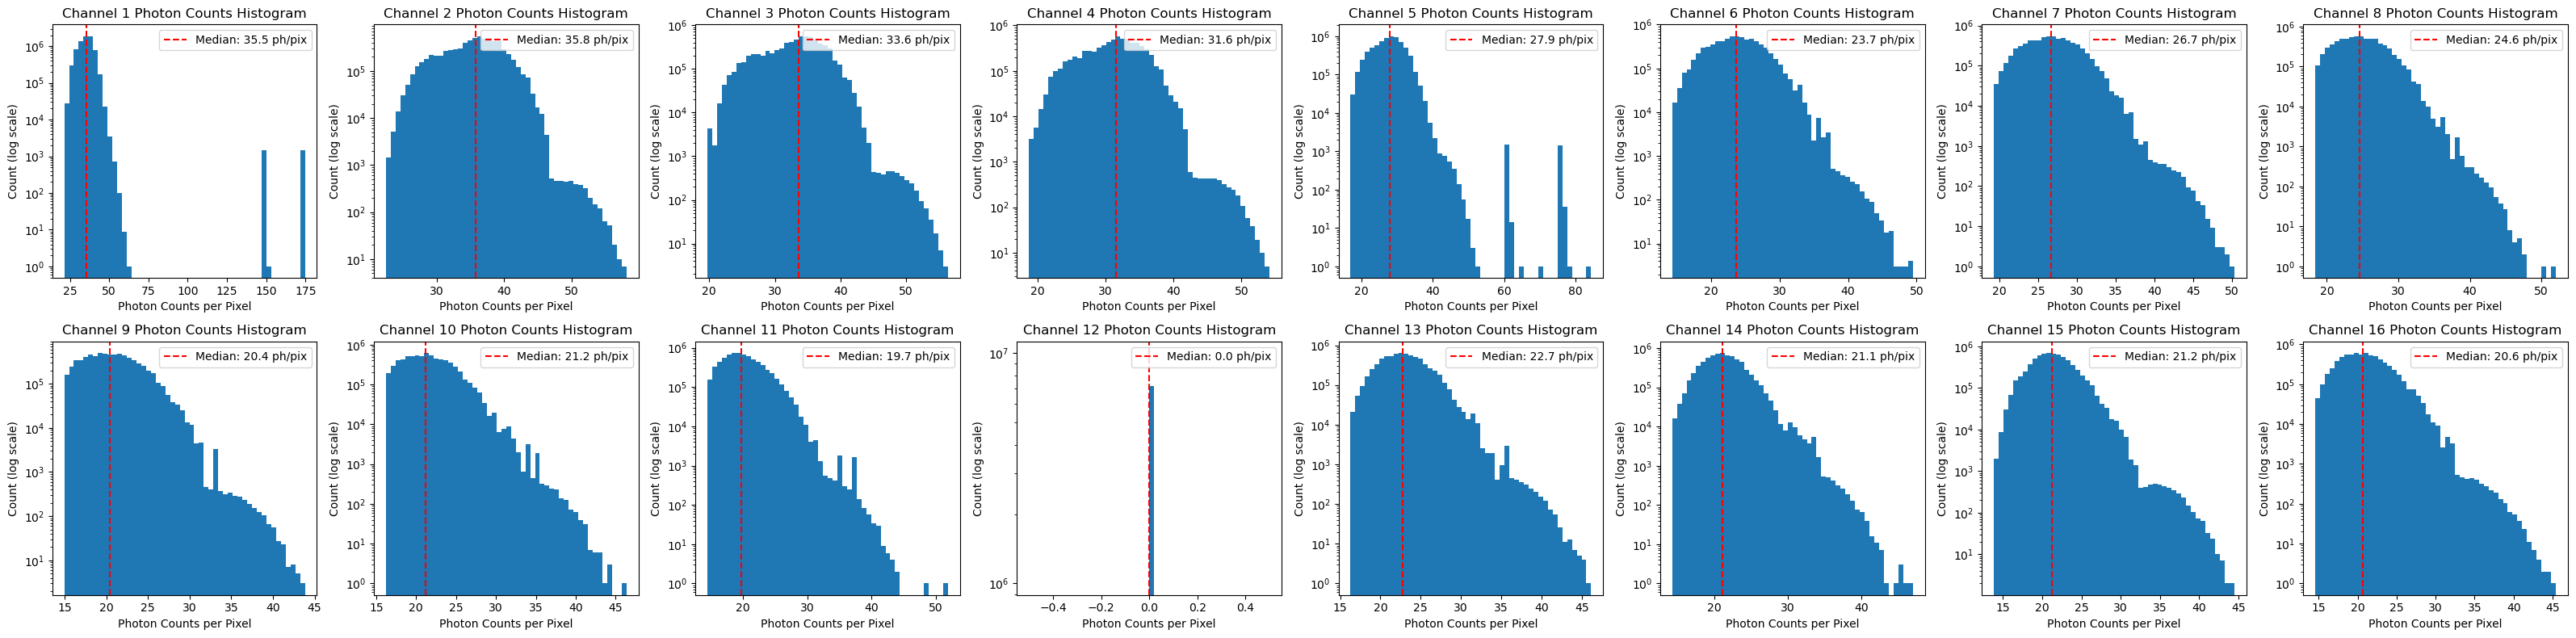

In [30]:
#Plot the histograms of the photon counts for each channel
fig, axes = plt.subplots(2, num_channels//2, figsize=(32, 8))
for i in range(num_channels):
    c0 = i * channel_width
    c1 = (i + 1) * channel_width
    channel = zenith_sky_1_data_photons[:, :, c0:c1]
    
    # Ignoring NaNs for histogram
    channel = channel[~np.isnan(channel)]
    axes[i//(num_channels//2), i%(num_channels//2)].hist(channel.flatten(), bins=50, log=True)
    axes[i//(num_channels//2), i%(num_channels//2)].set_title(f"Channel {i+1} Photon Counts Histogram")
    axes[i//(num_channels//2), i%(num_channels//2)].set_xlabel("Photon Counts per Pixel")
    axes[i//(num_channels//2), i%(num_channels//2)].set_ylabel("Count (log scale)") 

    # axvline for the median photon count in this channel
    median_photon_count = np.median(channel)
    axes[i//(num_channels//2), i%(num_channels//2)].axvline(median_photon_count, color='red', linestyle='dashed', label=f'Median: {median_photon_count:.1f} ph/pix')
    axes[i//(num_channels//2), i%(num_channels//2)].legend()
plt.tight_layout()
plt.show()

## Channel 2 Injection

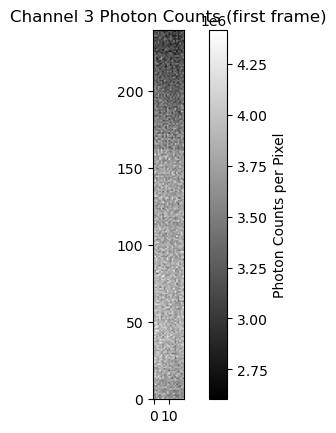

In [23]:
channel = 2
c0 = channel * channel_width
c1 = (channel + 1) * channel_width
ch2 = zenith_sky_1_data_photons[:, :, c0:c1]
plt.imshow(ch2[0], cmap='gray', origin='lower')
plt.title(f"Channel {channel+1} Photon Counts (first frame)")
plt.colorbar(label="Photon Counts per Pixel")
plt.show()

In [24]:
# For IRTF, the pixel scale is 0.27" and the diffraction limited psf has a FWHM of 0.84" 
# Determine the FWHM in pixels
pixel_scale = 0.27 # arcsec/pixel
FWHM_arcsec = 0.84 # arcsec
FWHM_pixels = FWHM_arcsec / pixel_scale
print(f"FWHM in pixels: {FWHM_pixels:.2f} pixels")

FWHM in pixels: 3.11 pixels


In [25]:
# inject a fake point source into ch2 
def gaussian_2d(x, y, x0, y0, sigma_x, sigma_y, amplitude):
    return amplitude * np.exp(-(((x - x0) ** 2) / (2 * sigma_x ** 2) + ((y - y0) ** 2) / (2 * sigma_y ** 2)))

def sigma(FWHM_pixels):
    # assume a FWHM of 3 pixels for the point source
    sigma = FWHM_pixels / (2 * np.sqrt(2 * np.log(2)))
    return sigma

In [26]:
def inject_point_source(image, x0, y0, FWHM_pixels, amplitude):
    sigma_x = sigma(FWHM_pixels)
    sigma_y = sigma(FWHM_pixels)
    
    # Create a grid of x and y coordinates
    y, x = np.indices(image.shape)
    
    # Generate the 2D Gaussian PSF
    psf = gaussian_2d(x, y, x0, y0, sigma_x, sigma_y, amplitude)

    # Add shot noise to the PSF (assuming Poisson statistics)
    psf_noisy = np.random.poisson(psf)
    
    # Inject the point source into the image
    injected_image = image + psf_noisy
    
    return injected_image

NameError: name 'ax' is not defined

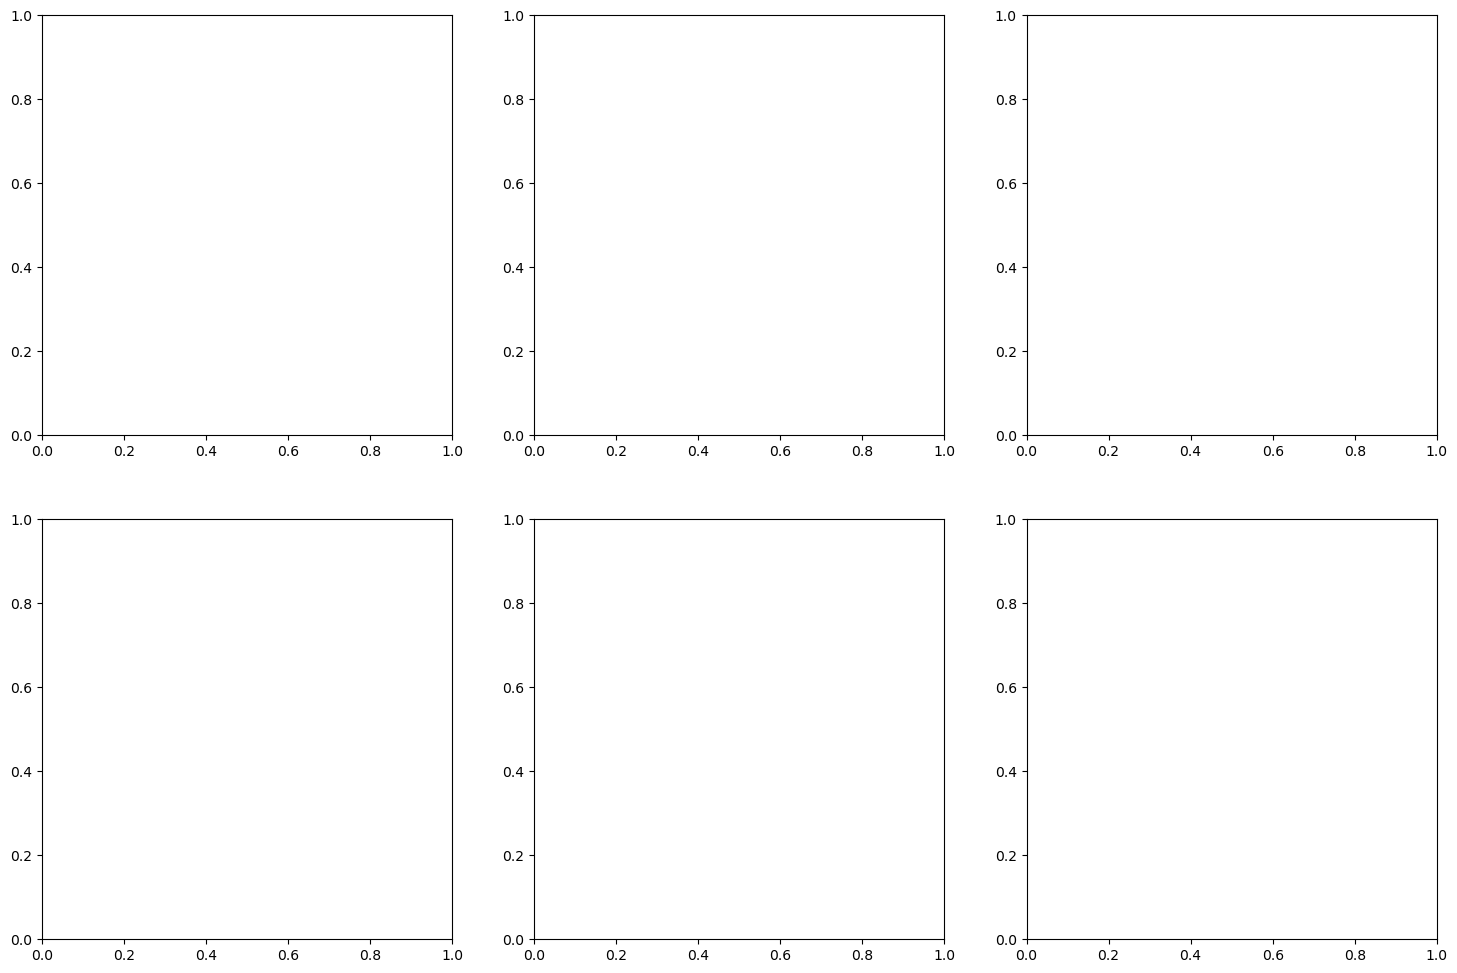

In [27]:
# Inject point source at (10, 100)
x0, y0 = 10, 100

# Amplitudes 
frac_amplitudes = [0.001, 0.1, 0.5, 1., 50, 100]
# For each amplitude, inject the point source and plot the result
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
for i, amp in enumerate(frac_amplitudes):
    injected_image = inject_point_source(ch2[0], x0, y0, FWHM_pixels, amp * sky_rate)

    # perform aperture photometry on the injected image to see if we can recover the injected flux
# perform aperture photometry on the injected image to see if we can recover the injected flux
    positions = [(x0, y0)]
    aperture = CircularAperture(positions, r=FWHM_pixels)
    annulus_aperture = CircularAnnulus(positions, r_in=FWHM_pixels*1.5, r_out=FWHM_pixels*2.5)
    aperture_masks = aperture.to_mask(method='center')
    annulus_masks = annulus_aperture.to_mask(method='center')
    aperture_data = aperture_masks[0].multiply(injected_image)
    annulus_data = annulus_masks[0].multiply(injected_image)
    aperture_sum = np.nansum(aperture_data)
    annulus_sum = np.nansum(annulus_data)
    annulus_area = annulus_aperture.area  # This is already just the annulus area
    background_per_pixel = annulus_sum / annulus_area
    signal = aperture_sum - (background_per_pixel * aperture.area)
    noise = np.sqrt(aperture_sum + (background_per_pixel * aperture.area))
    snr = signal / noise if noise > 0 else 0

    # Draw the annulus and aperture on the image
    aperture.plot(ax, color='red', lw=0.5)
    annulus_aperture.plot(ax, color='blue', lw=0.5)


    ax = axes[i//3, i%3]
    im = ax.imshow(injected_image, cmap='gray', origin='lower')
    ax.set_title(f"Injected Point Source (Amplitude: {amp} * sky_rate )\nSNR: {snr:.2f}")
    plt.colorbar(im, ax=ax, pad=0.01)

In [ ]:
# Draw apertures for photometry and compute the signal-to-noise ratio for each injected source


Text(0.5, 1.0, 'Injected Point Source (Amplitude: 908765.7 ph/pix)\nSNR: 2859.69')